<div style="background:linear-gradient(120deg,#1f6feb 0%,#6f42c1 60%,#4c9a2a 100%);color:#fff;padding:34px 30px;border-radius:16px;text-align:center;box-shadow:0 8px 26px rgba(60,60,120,.30);"><div style="font-size:34px;font-weight:900;">🔍 Insight Engine</div><div style="font-size:17px;margin-top:8px;opacity:.95;">Mining 112,481 real customer complaints for the top problems to fix — the complete end-to-end notebook</div><div style="font-size:13px;margin-top:12px;opacity:.9;">Embeddings → Clustering → TF-IDF → Severity → Priority → LLM naming</div></div>

### 📘 About this notebook
This single notebook walks through the **entire project from start to finish** with explanations and live outputs. It is a **read-and-run study document**: it loads the artifacts already produced by the pipeline (the saved embeddings, clustered data, and final results) so it runs end-to-end in a couple of minutes — instead of re-running the ~75-minute embedding job or the paid LLM calls.

**Colour legend used throughout:**

<div style="background:linear-gradient(120deg,#1f6feb,#274b8f);color:#fff;padding:7px 16px;border-radius:8px;display:inline-block;font-weight:700;">🔷 BLUE = phase header</div>&nbsp;&nbsp;<div style="background:#6f42c1;color:#fff;padding:7px 16px;border-radius:8px;display:inline-block;font-weight:700;">🟣 PURPLE = step / sub-header</div>&nbsp;&nbsp;<div style="background:#e8f6d8;border-left:7px solid #4c9a2a;color:#2f4f1a;padding:7px 16px;border-radius:8px;display:inline-block;font-weight:700;">💚 GREEN = insight / takeaway</div>

> **Golden rule of this project:** real public data only, no fabrication. Every number below traces back to a real complaint.

<div style="background:#6f42c1;color:#ffffff;padding:10px 20px;border-radius:9px;font-size:17px;font-weight:700;margin-top:6px;">⚙️ Setup — imports and paths</div>

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 90)

# Paths are relative to this notebook (notebooks/).
DATA = os.path.join("..", "data")
OUT  = os.path.join("..", "outputs")
APP  = os.path.join("..", "app")
print("Environment ready. Libraries: pandas", pd.__version__, "| numpy", np.__version__)

Environment ready. Libraries: pandas 3.0.3 | numpy 2.5.1


<div style="background:linear-gradient(120deg,#1f6feb 0%,#274b8f 100%);color:#ffffff;padding:18px 26px;border-radius:12px;font-size:23px;font-weight:800;box-shadow:0 4px 14px rgba(31,111,235,.30);">🔷 Phase 1 — The Data (source, scope & EDA)</div>

**The goal of this phase:** get real, defensible data and *understand it thoroughly* before building anything. If the data is wrong, everything built on it is wrong.

<div style="background:#6f42c1;color:#ffffff;padding:10px 20px;border-radius:9px;font-size:17px;font-weight:700;margin-top:6px;">🟣 1.1 The source — CFPB, and why not scraping</div>

We use the **CFPB Consumer Complaint Database** — U.S. government open data. The key field is the **narrative**: the customer's own written story. We deliberately chose it over scraping app-store reviews, which violates terms of service, is unreliable, and raises privacy issues. *'Publicly visible' is not the same as 'free and safe to bulk-collect.'*

<div style="background:#6f42c1;color:#ffffff;padding:10px 20px;border-radius:9px;font-size:17px;font-weight:700;margin-top:6px;">🟣 1.2 EDA on the full 8.5 GB file (chunked / out-of-core)</div>

The raw file is **8.5 GB / 17.1M rows** — far bigger than memory. We profiled it by reading it in **chunks** of 200,000 rows and accumulating summary statistics (see `scan_data.py`). Key findings from that scan:
- 17.1M complaints; only **3.8M (22%)** have a written narrative (it is opt-in).
- Narratives only exist **from 2015 onward**, so the oldest rows look empty.
- **Product labels are inconsistent** — the same product appears under multiple names.

We then extracted our scope: **credit-card complaints, with a narrative, from 2023 onward**. Below is that real extracted slice.

In [2]:
raw = pd.read_parquet(os.path.join(DATA, "creditcard_complaints.parquet"))
print(f"Extracted credit-card slice: {len(raw):,} complaints, {raw.shape[1]} columns")
print(f"Date range: {raw['Date received'].min().date()}  ->  {raw['Date received'].max().date()}")
print("\nComplaints per year:")
print(raw['Date received'].dt.year.value_counts().sort_index().to_string())

Extracted credit-card slice: 124,962 complaints, 16 columns
Date range: 2023-01-01  ->  2026-07-02

Complaints per year:
Date received
2023    32077
2024    35452
2025    41532
2026    15901


In [3]:
# A peek at the real raw narratives (the text our engine will read)
raw[["Date received", "Product", "Consumer complaint narrative"]].head(3)

,Date received,Product,Consumer complaint narrative
0,2025-12-16 16:27:27,Credit card,"In XX/XX/year>, XXXX, through XXXX, applied charges to my account that were higher tha..."
1,2026-01-14 17:36:29,Credit card,"On XX/XX/year>, Adobe replied only to say they would keep the case open and restated m..."
2,2026-02-19 03:42:52,Credit card,Chase is using many tactics to steal money from consumers and they must stop. I would ...


<div style="background:#e8f6d8;border-left:7px solid #4c9a2a;color:#2f4f1a;padding:13px 20px;border-radius:9px;font-size:15px;">💚 <b>Insight:</b> the extracted slice has a healthy spread across 2023–2026 and every row carries a real written narrative — exactly the fuel the NLP engine needs. This is also where we caught a silent date-corruption bug (see the Discoveries section at the end).</div>

<div style="background:linear-gradient(120deg,#1f6feb 0%,#274b8f 100%);color:#ffffff;padding:18px 26px;border-radius:12px;font-size:23px;font-weight:800;box-shadow:0 4px 14px rgba(31,111,235,.30);">🔷 Phase 2 — Cleaning the Text</div>

**The goal:** remove noise (duplicates, privacy masks) *without destroying meaning*, so the themes that come out are trustworthy.

<div style="background:#6f42c1;color:#ffffff;padding:10px 20px;border-radius:9px;font-size:17px;font-weight:700;margin-top:6px;">🟣 2.1 What was messy, and our conservative fixes</div>

We measured the mess first: ~**12,268 exact duplicates** (~10%), **75.9%** of narratives contain `XXXX` privacy masks, **42.5%** contain money masks like `{$70.00}`. We removed duplicates, merged the two product labels, and turned privacy masks into **neutral placeholders** (`<redacted>`, `<date>`, `<money>`) instead of deleting them — deleting would shatter sentences. The original text is always kept for auditability. The logic lives in `text_cleaning.py`.

In [4]:
from text_cleaning import clean_narrative   # the reusable cleaner (regex-based)

sample_raw = raw["Consumer complaint narrative"].iloc[0]
print("BEFORE (raw):\n", sample_raw[:280], "...\n")
print("AFTER  (clean):\n", clean_narrative(sample_raw)[:280], "...")

BEFORE (raw):
 In XX/XX/year>, XXXX, through XXXX, applied charges to my account that were higher than what I originally agreed to and used. I noticed the overcharges about four months later and immediately disabled autopay through my bank and disputed the charges with both companies. XXXX has  ...

AFTER  (clean):
 In <date> , <redacted> , through <redacted> , applied charges to my account that were higher than what I originally agreed to and used. I noticed the overcharges about four months later and immediately disabled autopay through my bank and disputed the charges with both companies. ...


In [5]:
# Before vs after row counts (raw slice vs cleaned dataset)
clean = pd.read_parquet(os.path.join(DATA, "full_complaints.parquet"))
before, after = len(raw), len(clean)
print(f"Before cleaning : {before:,} complaints")
print(f"Removed         : {before - after:,}  (exact duplicates + very short texts)")
print(f"After cleaning  : {after:,} clean, unique, model-ready complaints")

Before cleaning : 124,962 complaints
Removed         : 12,481  (exact duplicates + very short texts)
After cleaning  : 112,481 clean, unique, model-ready complaints


<div style="background:#e8f6d8;border-left:7px solid #4c9a2a;color:#2f4f1a;padding:13px 20px;border-radius:9px;font-size:15px;">💚 <b>Insight:</b> 124,962 → 112,481. Removing ~10% duplicates matters a lot: duplicates would fake-inflate how common a problem looks and corrupt the final ranking.</div>

<div style="background:linear-gradient(120deg,#1f6feb 0%,#274b8f 100%);color:#ffffff;padding:18px 26px;border-radius:12px;font-size:23px;font-weight:800;box-shadow:0 4px 14px rgba(31,111,235,.30);">🔷 Phase 3 — The AI Engine (the core NLP)</div>

This is where the computer 'reads' the complaints and finds the problems, in five steps.

<div style="background:#6f42c1;color:#ffffff;padding:10px 20px;border-radius:9px;font-size:17px;font-weight:700;margin-top:6px;">🟣 3.1 Embeddings — turn each complaint into 384 numbers that capture meaning</div>

An **embedding** is a list of numbers representing a text's *meaning*: complaints that mean similar things get similar numbers. Model: **all-MiniLM-L6-v2** (sentence-transformers). Embedding all 112k took ~**75 minutes** on CPU, so it was run once and saved — we just load it.

In [6]:
emb = np.load(os.path.join(DATA, "full_embeddings.npy"))
print(f"Embeddings matrix: {emb.shape[0]:,} complaints  ×  {emb.shape[1]} numbers each")
print("One complaint as a 384-number 'meaning-vector' (first 8 numbers shown):")
print(np.round(emb[0][:8], 4))

Embeddings matrix: 112,481 complaints  ×  384 numbers each
One complaint as a 384-number 'meaning-vector' (first 8 numbers shown):
[-0.1232  0.0405 -0.018   0.0259 -0.0031  0.0351  0.0645 -0.0363]


<div style="background:#e8f6d8;border-left:7px solid #4c9a2a;color:#2f4f1a;padding:13px 20px;border-radius:9px;font-size:15px;">💚 <b>Insight:</b> every complaint is now a point in 384-dimensional 'meaning-space'. Similar complaints sit close together — which is what makes the next step (grouping) possible.</div>

<div style="background:#6f42c1;color:#ffffff;padding:10px 20px;border-radius:9px;font-size:17px;font-weight:700;margin-top:6px;">🟣 3.2 Clustering — group similar complaints into themes with KMeans</div>

**KMeans** splits the points into K groups (we chose **K = 12**): it places 12 centres, assigns each complaint to its nearest centre, moves centres to the average of their members, and repeats until stable. Nobody labelled the themes — this is **unsupervised learning**. The clustered data is loaded below (theme number already assigned).

In [7]:
df = pd.read_parquet(os.path.join(DATA, "full_clustered.parquet"))
sizes = df["theme"].value_counts().sort_index()
print("Complaints per theme (0–11):")
for tid, n in sizes.items():
    print(f"  theme {tid:>2}: {n:>6,}  ({n/len(df)*100:4.1f}%)")

Complaints per theme (0–11):
  theme  0: 15,077  (13.4%)
  theme  1:  5,891  ( 5.2%)
  theme  2: 14,315  (12.7%)
  theme  3:  6,862  ( 6.1%)
  theme  4:  9,651  ( 8.6%)
  theme  5:  9,888  ( 8.8%)
  theme  6:  4,151  ( 3.7%)
  theme  7: 10,904  ( 9.7%)
  theme  8: 12,604  (11.2%)
  theme  9:  9,214  ( 8.2%)
  theme 10:  6,413  ( 5.7%)
  theme 11:  7,511  ( 6.7%)


<div style="background:#6f42c1;color:#ffffff;padding:10px 20px;border-radius:9px;font-size:17px;font-weight:700;margin-top:6px;">🟣 3.3 TF-IDF — find the words that make each theme distinctive</div>

**TF-IDF** scores words that are common inside one theme but rare overall — 'the words that make this group special'. We use the top words as each theme's keyword label (dropping placeholder noise like *redacted, date, money*).

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
NOISE = {"redacted","date","money","xxxx","xx","account","credit","card","credit card","com","www"}
vec = TfidfVectorizer(max_features=4000, stop_words="english", ngram_range=(1,2))
tfidf = vec.fit_transform(df["narrative_clean"]); terms = np.array(vec.get_feature_names_out())

def top_keywords(tid, n=6):
    rows = np.where(df["theme"].values == tid)[0]
    order = np.asarray(tfidf[rows].mean(axis=0)).ravel().argsort()[::-1]
    out = [terms[i] for i in order if terms[i] not in NOISE and
           not any(p in NOISE for p in terms[i].split())]
    return ", ".join(out[:n])

for tid in range(df["theme"].nunique()):
    print(f"theme {tid:>2}:  {top_keywords(tid)}")

theme  0:  charges, fraud, fraudulent, bank, charge, did
theme  1:  points, offer, bonus, chase, rewards, american
theme  2:  dispute, merchant, refund, charge, received, did
theme  3:  report, accounts, identity, theft, identity theft, opened
theme  4:  did, company, payment, called, received, bank
theme  5:  reporting, consumer, information, act, 15, debt
theme  6:  late, payment, late payment, payments, usc, 15 usc
theme  7:  bank, number, application, received, called, company


theme  8:  payment, bank, balance, late, payments, pay
theme  9:  balance, payment, fee, charged, pay, paid
theme 10:  capital, payment, closed, accounts, payments, fraud
theme 11:  closed, close, bank, accounts, closure, balance


<div style="background:#e8f6d8;border-left:7px solid #4c9a2a;color:#2f4f1a;padding:13px 20px;border-radius:9px;font-size:15px;">💚 <b>Insight:</b> the keywords already tell a story — fraud/unauthorized, disputes, credit-reporting, payments — proving the clusters are meaningful, not random.</div>

<div style="background:#6f42c1;color:#ffffff;padding:10px 20px;border-radius:9px;font-size:17px;font-weight:700;margin-top:6px;">🟣 3.4 Severity — how bad is each theme (not just how common)?</div>

Severity combines two honest signals, both 0–1: **VADER** sentiment negativity, and the share of complaints mentioning **high-stakes words** (fraud, stolen, identity, legal…). These were already computed per complaint (`negativity`, `severe_flag`); we average them per theme.

In [9]:
g = df.groupby("theme")
theme = pd.DataFrame({
    "count": g.size(),
    "negativity": g["negativity"].mean().round(3),
    "severe_share": g["severe_flag"].mean().round(3),
})
theme["severity"] = ((theme["negativity"] + theme["severe_share"]) / 2).round(3)
theme["share_%"]  = (theme["count"] / len(df) * 100).round(1)
theme["priority"] = (theme["share_%"] * theme["severity"]).round(2)
theme.sort_values("priority", ascending=False)

,count,negativity,severe_share,severity,share_%,priority
theme,,,,,,
0,15077,0.675,0.877,0.776,13.4,10.40
2,14315,0.712,0.356,0.534,12.7,6.78
5,9888,0.476,0.447,0.462,8.8,4.07
8,12604,0.451,0.237,0.344,11.2,3.85
7,10904,0.419,0.327,0.373,9.7,3.62
3,6862,0.467,0.645,0.556,6.1,3.39
4,9651,0.482,0.263,0.372,8.6,3.20
10,6413,0.482,0.405,0.444,5.7,2.53
11,7511,0.394,0.229,0.312,6.7,2.09


<div style="background:#6f42c1;color:#ffffff;padding:10px 20px;border-radius:9px;font-size:17px;font-weight:700;margin-top:6px;">🟣 3.5 Priority — the smart ranking (Volume × Severity)</div>

**Priority = Volume% × Severity** surfaces problems that are both common AND serious — the classic business *priority matrix*, not a popularity contest.

<div style="background:#6f42c1;color:#ffffff;padding:10px 20px;border-radius:9px;font-size:17px;font-weight:700;margin-top:6px;">🟣 3.6 LLM naming — Google Gemini gives each theme a human name</div>

The clusters started as 'Theme 0, 1, 2…'. We sent each theme's keywords + 3 real examples to **Google Gemini** (free tier) and asked for a short name + description as strict JSON, with a keyword fallback if a call failed. The key is read from a git-ignored `.env`. Below is the final named, ranked result table (`theme_final_full.csv`).

In [10]:
final = pd.read_csv(os.path.join(OUT, "theme_final_full.csv")).sort_values("rank")
final[["rank","name","share_%","severity","priority","description"]].reset_index(drop=True)

,rank,name,share_%,severity,priority,description
0,1,Unauthorized Charges and Fraud Disputes,13.4,0.776,10.40,"Complaints regarding fraudulent transactions, improper dispute handling, and suspiciou..."
1,2,Billing and Merchant Charge Disputes,12.7,0.534,6.78,"Complaints regarding unauthorized charges, overbilling, undelivered goods, and denied ..."
2,3,Inaccurate Credit Reporting and Discrepancies,8.8,0.462,4.07,Complaints regarding incorrect account details and non-compliant reporting on consumer...
3,4,Payment Processing and Balance Errors,11.2,0.344,3.85,"Issues related to unauthorized, misdirected, duplicate, or delayed credit card payment..."
4,5,Unauthorized Credit Card Applications and Openings,9.7,0.373,3.62,Complaints regarding credit cards opened or applied for without the customer's knowled...
5,6,Identity Theft and Fraudulent Accounts,6.1,0.556,3.39,"Issues related to fraudulent accounts, identity theft, and disputed credit report info..."
6,7,Merchant Disputes and Poor Communication,8.6,0.373,3.21,"Customer issues regarding unfulfilled merchant resolutions, unresponsive companies, an..."
7,8,Unexpected Account Closures and Fraud,5.7,0.444,2.53,Customers report unexpected account closures by Capital One following fraud disputes o...
8,9,Unauthorized or Improper Account Closure,6.7,0.311,2.08,Complaints regarding unexpected account closures or banks failing to correctly report ...
9,10,High Interest Rates and Fees,8.2,0.217,1.78,"Complaints regarding high interest rates, predatory loan terms, and unaffordable month..."


<div style="background:linear-gradient(120deg,#1f6feb 0%,#274b8f 100%);color:#ffffff;padding:18px 26px;border-radius:12px;font-size:23px;font-weight:800;box-shadow:0 4px 14px rgba(31,111,235,.30);">🔷 Visualising the Results</div>

<div style="background:#6f42c1;color:#ffffff;padding:10px 20px;border-radius:9px;font-size:17px;font-weight:700;margin-top:6px;">🟣 The priority matrix (right = common, up = severe, bubble = priority)</div>

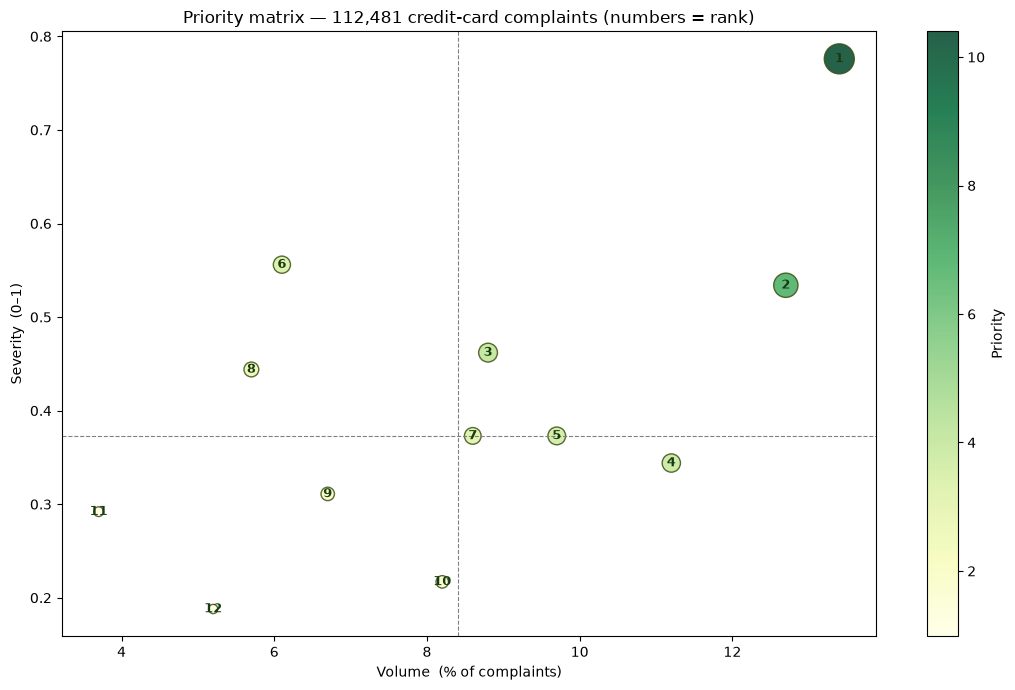

In [11]:
t = final
plt.figure(figsize=(11,7))
plt.scatter(t["share_%"], t["severity"], s=t["priority"]*45, c=t["priority"],
            cmap="YlGn", edgecolors="#3B5015", alpha=.85)
for _, r in t.iterrows():
    plt.annotate(str(r["rank"]), (r["share_%"], r["severity"]),
                 ha="center", va="center", fontsize=9, fontweight="bold", color="#173a10")
plt.axvline(t["share_%"].median(), color="grey", ls="--", lw=.8)
plt.axhline(t["severity"].median(), color="grey", ls="--", lw=.8)
plt.title("Priority matrix — 112,481 credit-card complaints (numbers = rank)")
plt.xlabel("Volume  (% of complaints)"); plt.ylabel("Severity  (0–1)")
plt.colorbar(label="Priority"); plt.tight_layout(); plt.show()

<div style="background:#6f42c1;color:#ffffff;padding:10px 20px;border-radius:9px;font-size:17px;font-weight:700;margin-top:6px;">🟣 Themes ranked by priority</div>

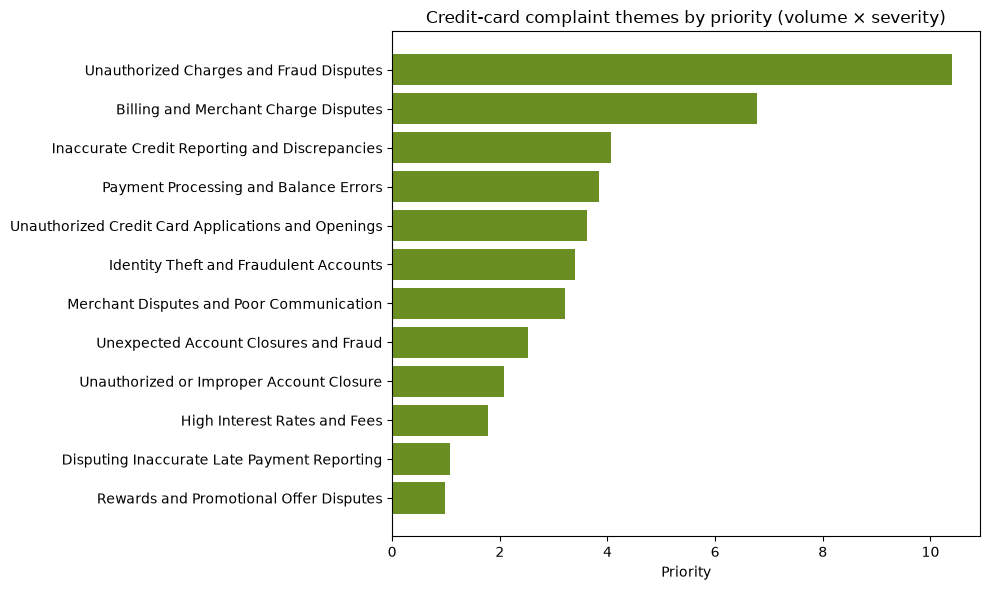

In [12]:
s = final.sort_values("priority")
plt.figure(figsize=(10,6))
plt.barh(s["name"], s["priority"], color="#6B8E23")
plt.title("Credit-card complaint themes by priority (volume × severity)")
plt.xlabel("Priority"); plt.tight_layout(); plt.show()

<div style="background:#6f42c1;color:#ffffff;padding:10px 20px;border-radius:9px;font-size:17px;font-weight:700;margin-top:6px;">🟣 The 2-D 'meaning-map' (384 dimensions squashed to 2 with PCA)</div>

**PCA** shrinks the 384-number vectors to 2 so we can *see* the clusters. Each dot is one complaint; colour = its theme.

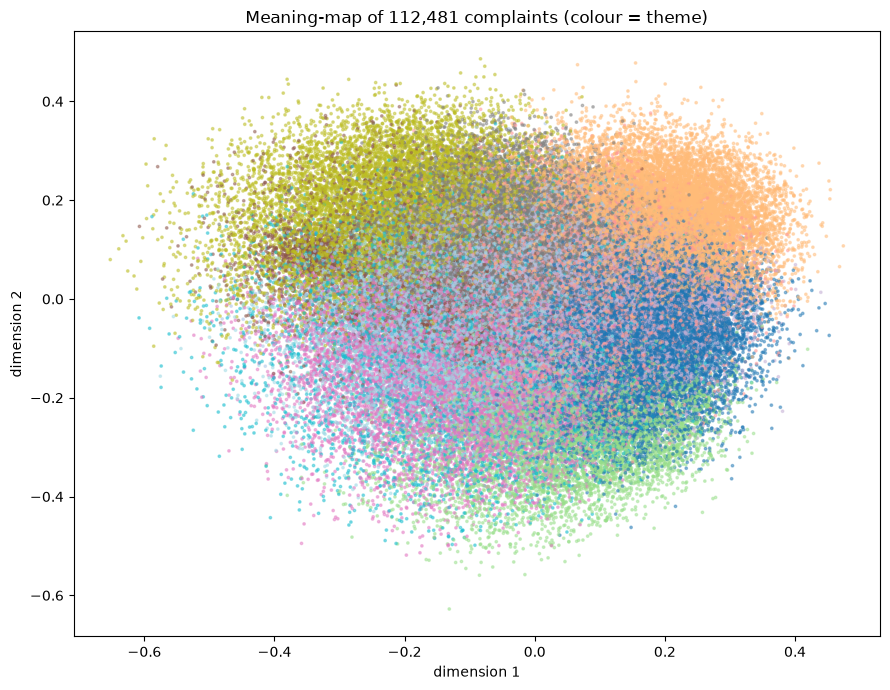

In [13]:
from sklearn.decomposition import PCA
coords = PCA(n_components=2, random_state=42).fit_transform(emb)
plt.figure(figsize=(9,7))
plt.scatter(coords[:,0], coords[:,1], c=df["theme"], cmap="tab20", s=3, alpha=.45)
plt.title("Meaning-map of 112,481 complaints (colour = theme)")
plt.xlabel("dimension 1"); plt.ylabel("dimension 2"); plt.tight_layout(); plt.show()

<div style="background:linear-gradient(120deg,#1f6feb 0%,#274b8f 100%);color:#ffffff;padding:18px 26px;border-radius:12px;font-size:23px;font-weight:800;box-shadow:0 4px 14px rgba(31,111,235,.30);">🔷 The Findings</div>

<div style="background:#e8f6d8;border-left:7px solid #4c9a2a;color:#2f4f1a;padding:13px 20px;border-radius:9px;font-size:15px;">💚 <b>Headline:</b> fraud and disputes dominate. <b>#1 Unauthorized Charges &amp; Fraud</b> is both the <b>most common (13.4%)</b> and the <b>most severe (0.78)</b> — the worst possible combination and an unambiguous 'fix-first'. Billing/merchant disputes and credit-reporting errors follow. Low-severity themes like rewards confusion correctly sink to the bottom even though they are fairly common — which is exactly why priority beats raw volume.</div>

<div style="background:linear-gradient(120deg,#1f6feb 0%,#274b8f 100%);color:#ffffff;padding:18px 26px;border-radius:12px;font-size:23px;font-weight:800;box-shadow:0 4px 14px rgba(31,111,235,.30);">🔷 Discoveries, Limitations & What's Next</div>

**🐞 The bug we caught:** a flat time-chart revealed dates were silently corrupted during chunked CSV extraction — pandas inferred the date column's type differently per chunk and the join coerced most to `NaT`. Fixed by typing dates per chunk and switching to **Parquet**. *Lesson: never trust a result that looks off; always re-validate output.*

**📈 More data → cleaner themes:** on an 18k sample, fraud smeared across ~3 overlapping clusters; on the full 112k it separated into distinct categories. More data = less noise.

**🧯 Honest limitations:** severity is a *proxy* (lexicon + hand-picked keywords), VADER can misread sarcasm, and KMeans needs K chosen up front. Stating this is a strength.

**🚀 What's next:** try HDBSCAN for a data-driven number of themes, a transformer sentiment model for severity, and a scheduled GitHub Actions refresh.

<div style="background:linear-gradient(120deg,#1f6feb,#6f42c1);color:#fff;padding:16px 24px;border-radius:12px;">🔗 <b>See it live:</b> the interactive <b>Streamlit dashboard</b> (<code>app/insight_app.py</code>) adds an upload-and-analyze tool; the <b>offline dashboard</b> (<code>docs/index.html</code>) is a static study version with a Questions &amp; Answers page.</div>